### Проблема Conv1D: Почему MSE «глухой» к частоте?

Функция потерь (MSE) считает разницу по вертикали (амплитуде) между оригинальной точкой и предсказанной.

Представь два сценария:

1. **Удар ключом:** Идеальный сигнал был $y = 0$, стал $y = 5$. Разница: $(0 - 5)^2 = 25$. Огромный штраф!
    
2. **Поломка подшипника (Высокая частота):** Сигнал стал вибрировать мелко, но быстро. Идеальный сигнал $y = \sin(t)$, сломанный $y = \sin(t) + 0.5\sin(10t)$. Максимальная разница по амплитуде здесь всего $0.5$. Штраф: $(0.5)^2 = 0.25$. Нейросеть думает: _"Да это просто легкий шум, ничего страшного"_.

Автоэнкодер на Conv1D пытается предсказать точное положение графика в каждую долю секунды. Для высокочастотного сигнала предсказать точную фазу почти нереально, поэтому сеть усредняет предсказание.

### Решение из мира Computer Vision: Спектрограммы

Вместо того чтобы заставлять модель смотреть на сырой график (Time Domain), инженеры переводят сигнал в **частотную область** (Frequency Domain) с помощью Оконного преобразования Фурье — **STFT** (Short-Time Fourier Transform).

**Как это работает:** Мы режем наш временной ряд на маленькие кусочки и для каждого кусочка задаем вопрос: _"А сколько в тебе басов? А сколько высоких частот?"_. В результате мы получаем 2D-матрицу:

- **Ось X:** Время
    
- **Ось Y:** Частота (Гц)
    
- **Цвет (пиксель):** Интенсивность (мощность) этой частоты в данный момент времени.
    

**Бум! Мы только что превратили скучный одномерный массив датчика в КАРТИНКУ (2D изображение).** Высокочастотная поломка теперь — это не мелкая рябь на графике, а **яркая горизонтальная полоса** в верхней части нашего изображения. А одиночный удар ключом — это просто узкая вертикальная вспышка.

### 1. Пишем код: Превращаем сигнал в картинку

Давай визуализируем это. В Python есть готовая функция для построения спектрограмм.

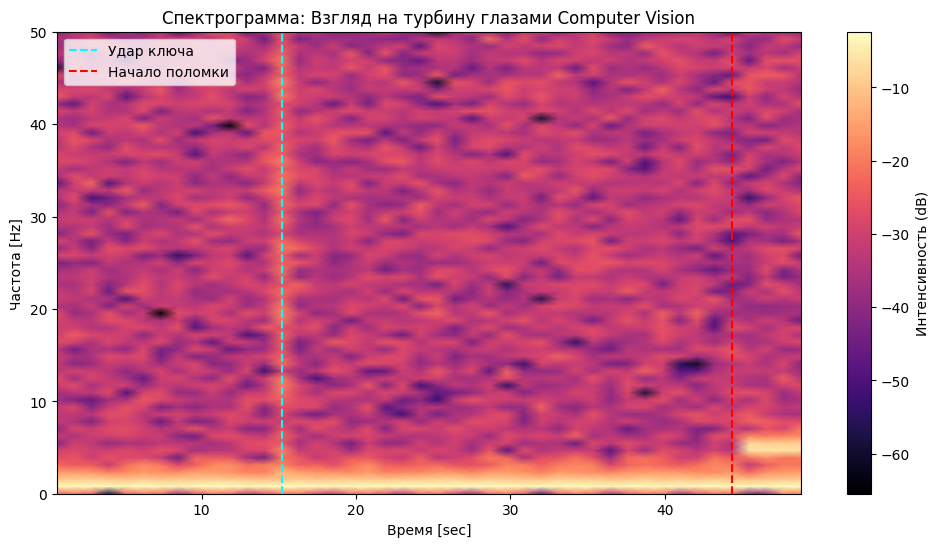

In [1]:
import matplotlib.pyplot as plt
import scipy.signal as signal
import numpy as np
import pandas as pd

np.random.seed(42)

t = np.linspace(0, 50, 5000)

# 1. Генерируем нормальную работу турбины
vibration = np.sin(2 * np.pi * 1 * t) + np.random.normal(0, 0.2, 5000)

# 2. ВНОСИМ АНОМАЛИИ
vibration[1500] += 5.0 # Единичный удар ключа
vibration[-500:] += 0.8 * np.sin(10 * np.pi * t[-500:]) # Поломка: высокочастотная вибрация в конце

df = pd.DataFrame({"Vibration": vibration})

# fs - частота дискретизации, допустим 100 точек в секунду (100 Гц)
fs = 100

# Считаем спектрограмму
# nperseg - размер окна Фурье (чем больше, тем точнее частота, но хуже время)
frequencies, times, Sxx = signal.spectrogram(df["Vibration"].values, fs=fs, nperseg=128)

plt.figure(figsize=(12, 6))
# Рисуем логарифм мощности
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')

plt.title('Спектрограмма: Взгляд на турбину глазами Computer Vision')
plt.ylabel('Частота [Hz]')
plt.xlabel('Время [sec]')
plt.colorbar(label='Интенсивность (dB)')

# Отметим зоны
plt.axvline(x=times[1500 * len(times) // 5000], color='cyan', linestyle='--', label='Удар ключа')
plt.axvline(x=times[4500 * len(times) // 5000], color='red', linestyle='--', label='Начало поломки')
plt.legend()
plt.show()

### 2. Архитектура Conv2D Автоэнкодера

Мы заменим 1D-свертки на 2D-свертки, которые будут бегать по картинке квадратом (например, 3x3 пикселя), выискивая геометрические формы (линии, пятна).

- Входной тензор должен иметь форму: [Batch, Channels, Height, Width]  
- сhannels = 1, так как у нас одна матрица интенсивности (черно-белая логика)

In [2]:
import torch
import torch.nn as nn

class SpectogramAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Сжимаем картинку, вытаскивая главные фичи
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Разжимаем фичи обратно в картинку того же размера
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Возвращаем 1 канал на выходе. 
            # Sigmoid используем, если мы нормализовали спектрограмму от 0 до 1.
            nn.ConvTranspose2d(in_channels=16, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded



>Важный технический нюанс: При использовании stride=2 размерность картинки делится пополам. Чтобы ConvTranspose2d смог разжать её ровно в исходный размер пиксель-в-пиксель, высота и ширина входной спектрограммы должны быть четными числами.

### 3. Подготовка данных для PyTorch
PyTorch не ест сырые матрицы из scipy. Нам нужно нормализовать данные и превратить их в тензоры правильной формы.

In [3]:
from sklearn.preprocessing import MinMaxScaler

# 1. Берем логарифм мощности, как мы делали на графике
Sxx_log = 10 * np.log10(Sxx)

# 2. Нормализуем данные от 0 до 1 (чтобы выход Sigmoid имел смысл)
scaler = MinMaxScaler()
Sxx_normalized = scaler.fit_transform(Sxx_log)

# 3. Превращаем в тензор
# Sxx_normalized имеет размер [Height, Width] (например 65х500)
# Нам нужен [Batch, Channels, Height, Width] -> (1, 1, 65, 500)
tensor_spectrogram = torch.tensor(Sxx_normalized, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

print(f"Форма входного тензора: {tensor_spectrogram.shape}")

Форма входного тензора: torch.Size([1, 1, 65, 44])


### 3. Логика поиска аномалий (Inference)

После того как модель обучена на нормальных данных, процесс поиска аномалии на новых данных выглядит так:

1. Прогоняем спектрограмму через сеть.
    
2. Считаем ошибку восстановления по формуле среднеквадратичного отклонения:
    

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2$$

3. Если ошибка (loss) превышает заданный порог, значит, на картинке появилось что-то, чего модель не может восстановить — это и есть наша поломка.  

Нейросеть не может обучиться на одной картинке. Нам нужно применить логику скользящего окна прямо к этой матрице, нарезая длинную спектрограмму на короткие «кадры».  

Поэтому также добавим **скользящее окно** (для создания датасета) и **Adam** (для обучения).
>Также решим проблему с нечетной размерностью по высоте спектрограммы (сейчас 65), в сверточных сетях со stride=2 (уменьшение в 2 раза) нечетные размеры вызывают проблемы при обратном восстановлении (декодер вернет четное число 64, и PyTorch выдаст ошибку несовпадения размеров)

In [4]:
# 1. Обрезаем нечетную размерность (65 -> 64)
Sxx_even = Sxx_normalized[:64, :]

window_size = 8 # Ширина кадра по времени
stride = 1      # Шаг скользящего окна
slices = []

# 2. Нарезаем матрицу скользящим окном по оси времени (колонкам)
for i in range(0, Sxx_even.shape[1] - window_size + 1, stride):
    window = Sxx_even[:, i : i + window_size]
    slices.append(window)

# 3. Превращает список кадров в PyTorch тензор
dataset = torch.tensor(np.array(slices), dtype=torch.float32).unsqueeze(1)

print(f"Форма готового датасета {dataset.shape}")

Форма готового датасета torch.Size([37, 1, 64, 8])


Теперь у нас батч из 37 отдельных спектрограмм! Это и есть замена pandas.rolling

#### Цикл обучения
Теперь, когда у нас есть батч из нарезанных картинок, мы можем запустить классический цикл обучения PyTorch. Мы будем учить модель на нормальных данных, чтобы она минимизировала ошибку восстановления.

Предположим, что первые 20 кадров нашего dataset — это абсолютно нормальная работа до удара ключом.

In [7]:
import torch.optim as optim

model = SpectogramAE()
optimizer = optim.Adam(model.parameters(), lr=0.05)
criterion = nn.MSELoss()

# Берем для обучения только "нормальные" данные (первые 20 окон)
train_data = dataset[:20]

epochs = 150
model.train() # Переводим в режим обучения

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = criterion(model(train_data), train_data)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 30 == 0:
        print(f"Эпоха [{epoch+1}/{epochs}], Ошибка (Loss): {loss.item():.4f}")

Эпоха [30/150], Ошибка (Loss): 0.0154
Эпоха [60/150], Ошибка (Loss): 0.0135
Эпоха [90/150], Ошибка (Loss): 0.0112
Эпоха [120/150], Ошибка (Loss): 0.0101
Эпоха [150/150], Ошибка (Loss): 0.0092


Предыдущий лог показывает что SpectogramAE отлично усвоил, как выглядит "нормальная" турбина (нижняя полоса базовой частоты + фоновый фиолетовый шум), и теперь умеет восстанавливать такие картинки почти со стопроцентной точностью.

Прогоним через эту обученную сеть все нарезанные кадры (включая те, которые она никогда не видела — с ударом ключа и с высокочастотной поломкой).

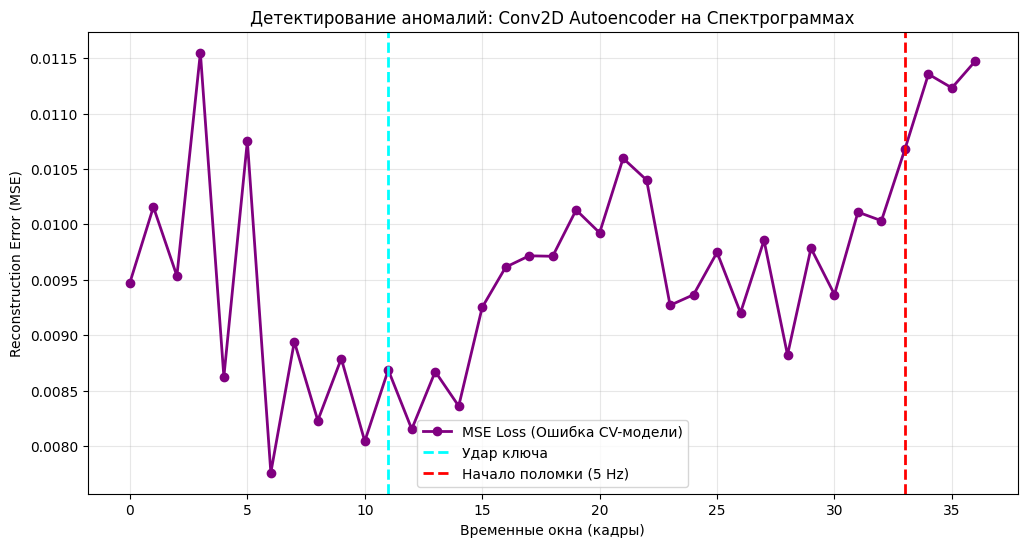

In [8]:
import matplotlib.pyplot as plt

# Переводим модель в режим предсказания (отключаем слои вроде Dropout/BatchNorm, если они есть)
model.eval()
anomaly_scores = []

# Отключаем расчет градиентов, чтобы не тратить память и ускорить процесс
with torch.no_grad():
    for window in dataset:
        # window имеет размер [1, 64, 8], добавляем размерность батча: [1,1,64,8]
        window = window.unsqueeze(0)
        loss = criterion(model(window), window)
        anomaly_scores.append(loss.item())

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(12, 6))
plt.plot(anomaly_scores, color='purple', linewidth=2, marker='o', label='MSE Loss (Ошибка CV-модели)')

# Рассчитываем, на какие окна пришлись наши события
total_windows = len(anomaly_scores)
strike_idx = int(15 / 50 * total_windows)
break_idx = int(45 / 50 * total_windows)

plt.axvline(x=strike_idx, color='cyan', linestyle='--', linewidth=2, label='Удар ключа')
plt.axvline(x=break_idx, color='red', linestyle='--', linewidth=2, label='Начало поломки (5 Hz)')

plt.title('Детектирование аномалий: Conv2D Autoencoder на Спектрограммах')
plt.xlabel('Временные окна (кадры)')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Результат слабый, данных маловато. Применим скользящее среднее как в Conv1D (сглаживание)

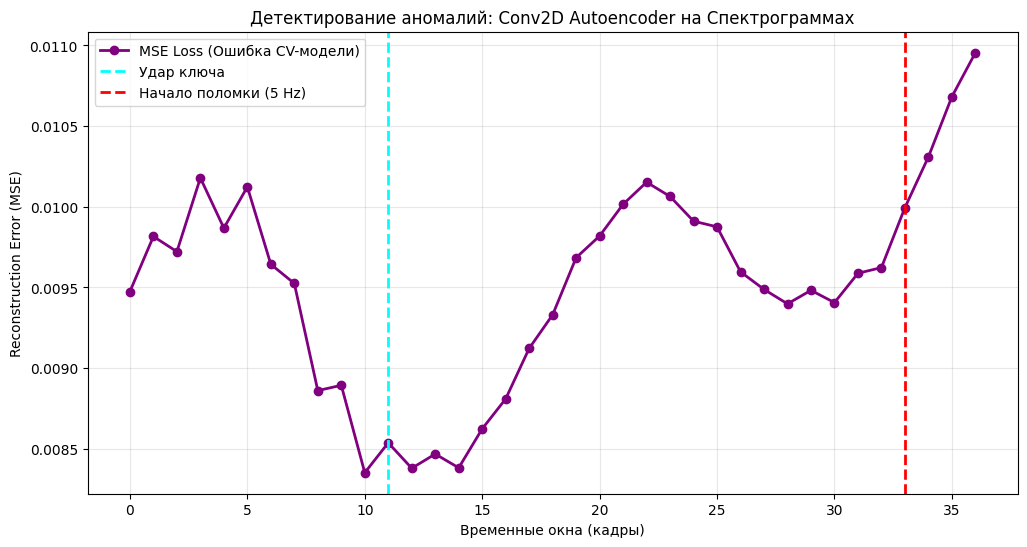

In [20]:
smoothed_scores = pd.Series(anomaly_scores).rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(smoothed_scores, color='purple', linewidth=2, marker='o', label='MSE Loss (Ошибка CV-модели)')

# Рассчитываем, на какие окна пришлись наши события
total_windows = len(smoothed_scores)
strike_idx = int(15 / 50 * total_windows)
break_idx = int(45 / 50 * total_windows)

plt.axvline(x=strike_idx, color='cyan', linestyle='--', linewidth=2, label='Удар ключа')
plt.axvline(x=break_idx, color='red', linestyle='--', linewidth=2, label='Начало поломки (5 Hz)')

plt.title('Детектирование аномалий: Conv2D Autoencoder на Спектрограммах')
plt.xlabel('Временные окна (кадры)')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Архитектура: Как это работает в Production

Когда мы уходим из уютного Jupyter Notebook в реальный цех, мы сталкиваемся с суровой правдой: датчик генерирует 100 точек в секунду, работает 24/7, и если мы будем запускать PyTorch на каждый новый чих, наш сервер сгорит через час.

Вот как выглядит классический промышленный пайплайн для потоковой обработки вибраций через CV-модели.

#### 1. Буферизация на лету (Ring Buffer)

Мы не считаем спектрограмму для каждой новой точки. Это бессмысленно и дорого. На стороне сервера (или прямо на контроллере турбины) создается **Кольцевой буфер (Ring Buffer)** — например, в Redis. Мы ждем, пока накопится, скажем, 1 секунда данных (100 точек). Как только секунда прошла — мы «откусываем» этот кусок и отправляем дальше, а буфер продолжает заполняться.

#### 2. Быстрый Worker (Препроцессинг)

Сырой массив из 100 точек прилетает в отдельный микросервис (Worker), написанный на Python, C++ или Go. Его единственная задача — мгновенно сделать Оконное преобразование Фурье (STFT) и отдать картинку (матрицу). Операции с Фурье очень быстрые, если не тянуть за собой тяжелые библиотеки.

#### 3. Inference Server (Отказ от голого PyTorch)

Никто не крутит модели в проде через `model.eval()` в обычном Python-скрипте. Это медленно и не утилизирует видеокарту.

- Твоя модель из PyTorch конвертируется в оптимизированный формат — **ONNX** или **TensorRT**.
    
- Модель загружается в специальный сервер (например, **NVIDIA Triton Inference Server**).
    
- **Dynamic Batching:** Если у тебя на заводе 50 турбин, Triton сам подождет пару миллисекунд, соберет 50 спектрограмм со всех турбин в один батч `[50, 1, 64, 8]` и за одну долю секунды прогонит их через GPU.
    

#### 4. Post-processing и Алерты (Бизнес-логика)

Triton выплевывает массив ошибок (MSE). Этот массив летит в последний сервис, который делает ровно то, что мы написали в коде:

- Применяет скользящее среднее `rolling().mean()`.
    
- Проверяет порог (Threshold) и плотность (Anomaly Density).
    
- Записывает результат в Time-Series базу данных (например, **InfluxDB** или **Prometheus**).
    

#### 5. Дашборды (Grafana)

Оператор на заводе вообще не знает про тензоры и автоэнкодеры. Он смотрит на красивый дашборд в **Grafana**, который берет данные из InfluxDB. Если наша сглаженная ошибка пробивает порог, Grafana зажигает красную лампочку и отправляет пуш-уведомление в Telegram или PagerDuty дежурному инженеру.

Мы разобрали архитектуру централизованного сервера. Но что, если эта турбина стоит на ветряке посреди Северного моря, где интернет ловит через раз, и гонять сырые данные на материк просто невозможно? Хочешь обсудить подход **Edge AI** — как сжать нашу PyTorch-модель до нескольких килобайт и заставить ее крутиться прямо на микроконтроллере (вроде ESP32 или Raspberry Pi) за 5 долларов, прикрученном изолентой к самой турбине?

### А что если турбина на ветряке посреди северного моря?

Ветряк в Северном море — это классический, эталонный юзкейс для **Edge AI (граничных вычислений)** и направления **TinyML** (Tiny Machine Learning).

Когда у тебя нет стабильного интернета (или спутниковый канал стоит как крыло самолета), ты физически не можешь стримить 100 Гц сырых данных на материк. Решение одно: перенести «мозг» (нашу нейросеть) прямо на датчик.

Но Python и PyTorch весят гигабайты, а у микроконтроллера за 5 баксов (вроде ESP32) всего около 520 КБ оперативной памяти (SRAM). Как мы запихнем туда наш `Conv2D` автоэнкодер?

Вот как выглядит суровый инженерный пайплайн сжатия и деплоя:

### 1. Квантование (Quantization)

Веса в твоей PyTorch-модели по умолчанию хранятся в формате `Float32` (32 бита на одно число с плавающей точкой). Для микроконтроллера это непозволительная роскошь. Мы применяем Post-Training Quantization (PTQ), принудительно переводя все веса слоев в целые числа `Int8` (8 бит). **Результат:** Модель мгновенно «худеет» в 4 раза, начинает потреблять в разы меньше батарейки и работает на слабом процессоре гораздо быстрее, теряя при этом от силы 1-2% точности.

### 2. Прунинг (Pruning)

Затем мы «отрубаем» мертвые связи. Специальный алгоритм анализирует обученную сеть, находит те веса в сверточных слоях, которые близки к нулю (то есть почти не влияют на результат), и просто удаляет их. Матрицы становятся разреженными (sparse), что экономит еще больше памяти.

### 3. Конвертация (ExecuTorch / TFLite Micro)

Голый PyTorch на ESP32 не запустится. Нам нужно скомпилировать сеть в чистый машинный код. До недавнего времени стандартом де-факто был экспорт модели через ONNX в TensorFlow Lite for Microcontrollers. Но сейчас экосистема изменилась: у PyTorch появился официальный инструмент **ExecuTorch** (пришел на смену PyTorch Mobile), который позволяет экспортировать модель в крошечный бинарный файл, готовый к запуску на «голом» железе.

### Жизнь на микроконтроллере (C++ Pipeline)

Когда ты прикрутишь плату изолентой к подшипнику турбины, пайплайн будет работать так:

- **Никакого Python:** Весь код пишется на C или C++.
    
- **Сбор данных:** Микроконтроллер непрерывно считывает вибрацию с пьезодатчика по аппаратной шине (I2C/SPI).
    
- **DSP на лету:** Нам больше не нужен `scipy.signal`. Мы делаем Оконное преобразование Фурье прямо на чипе с помощью оптимизированных Си-библиотек (например, ARM CMSIS-DSP). Математика там написана так, что спектрограмма считается за миллисекунды.
    
- **Inference:** Полученная спектрограмма скармливается в нашу сжатую `Int8` модель.
    
- **Бизнес-логика:** Наше скользящее среднее и проверка порога считаются там же обычным `if/else` на C++.
    

### Итог

Ветряк молчит неделями. Он не тратит дорогущий трафик и экономит энергию. Модель локально варится в своих спектрограммах. Но как только нейросеть замечает ту самую полосу на 5 Гц и ошибка пробивает порог, микроконтроллер просыпается, включает радиомодуль и отправляет на материк всего один MQTT-пакет весом в 10 байт: `{"status": "ALARM", "id": 42}`.

Магия? Нет, грамотная дата-инженерия.

Теперь ты прошел весь путь от `Pandas` и изоляционного леса до Computer Vision и развертывания на микроконтроллерах. Куда двинемся дальше: хочешь разобрать, как дообучать эту модель прямо на ветряке (On-device learning), если со временем из-за физического износа нормальный звук турбины немного изменится, или вернемся к Python и посмотрим на то, как временные ряды предсказывают Трансформеры?